# 1D CNN TFLite CPU Single-Patient Evaluation & Prediction Pipeline (STRIDE = 5s)

Multi-target intraoperative prediction across **19 Vital & Biomarker Signals** with **600-Second Lookback Window ($W=600\text{s}$)** and **$\text{STRIDE} = 5\text{s}$** for a single patient CSV input file:
1. **`Future_Hypotension`** (MAP < 65 mmHg within 10 minutes)
2. **`Future_Hypoxia`** (SpO2 < 90% within 10 minutes)
3. **`Future_Tachycardia`** (HR > 100 bpm within 10 minutes)

### Key Highlights & Features
- **Single-Patient Input**: Evaluates predictions for a specific patient file (e.g., `patient_1001_1hz.csv`) loaded from `patient_labeled_data`.
- **CPU Optimization**: Accelerated using `tflite_runtime` with multi-threaded XNNPACK CPU delegates and strided batch tensor allocation.
- **5-Second Stride Resolution**: Evaluates predictions at every 5-second interval ($W=600\text{s}, \text{STRIDE}=5\text{s}$).
- **Global Feature Scaler**: Uses exact mean/std parameters from `scaler_1d_cnn.json`.
- **CSV Export**: Outputs predictions to `cnn_single_patient_predictions_<patient_id>.csv`.

In [1]:
import os
import glob
import json
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
import tflite_runtime.interpreter as tflite

# ======================================================
# Single Patient CSV File Input Selection
# ======================================================
PATIENT_CSV_FILENAME = "patient_1002_1hz.csv"  # Specify target patient CSV filename here

WINDOW_SIZE = 600
STRIDE = 5

base_dir = os.getcwd()
candidates = [
    os.path.join(base_dir, "patient_labeled_data"),
    os.path.join(base_dir, "..", "patient_labeled_data"),
    os.path.join(base_dir, "..", "..", "patient_labeled_data")
]
input_dir = next((c for c in candidates if os.path.exists(c)), candidates[1])

# Resolve target patient CSV path
target_csv_path = os.path.join(input_dir, PATIENT_CSV_FILENAME)
if not os.path.exists(target_csv_path):
    avail = sorted(glob.glob(os.path.join(input_dir, "patient_*_1hz.csv")))
    if avail:
        target_csv_path = avail[0]
        PATIENT_CSV_FILENAME = os.path.basename(target_csv_path)

base_features = [
    "Solar8000/HR", "Solar8000/ART_SBP", "Solar8000/ART_DBP", "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2", "Solar8000/RR_CO2", "Solar8000/ETCO2", "Primus/FIO2", "Solar8000/BT"
]
engineered_features = [
    "Feature_Pulse_Pressure", "Feature_Shock_Index", "Feature_Modified_Shock_Index",
    "Feature_Rate_Pressure_Product", "Feature_HR_Mean_60s", "Feature_HR_Std_60s",
    "Feature_HR_Delta_60s", "Feature_MBP_Mean_60s", "Feature_MBP_Std_60s", "Feature_MBP_Delta_60s"
]
features = base_features + engineered_features
target_cols = ["Future_Hypotension", "Future_Hypoxia", "Future_Tachycardia"]

# Load Scaler Parameters
scaler_candidates = [
    os.path.join(base_dir, "scaler_1d_cnn.json"),
    os.path.join(base_dir, "CNN", "scaler_1d_cnn.json"),
    os.path.join(base_dir, "..", "CNN", "scaler_1d_cnn.json")
]
scaler_file = next((c for c in scaler_candidates if os.path.exists(c)), "scaler_1d_cnn.json")

with open(scaler_file, "r") as f:
    scaler_dict = json.load(f)

mean_vals = np.array([scaler_dict["mean"][f] for f in features], dtype=np.float32)
std_vals = np.array([scaler_dict["std"][f] for f in features], dtype=np.float32)
std_vals[std_vals == 0] = 1.0

print(f"Target Patient File : {target_csv_path}")
print(f"Loaded Scaler File  : {scaler_file}")
print(f"Config              : WINDOW_SIZE={WINDOW_SIZE}s, STRIDE={STRIDE}s")

Target Patient File : /home/logan78/Desktop/SiLabs/CNN/../patient_labeled_data/patient_1002_1hz.csv
Loaded Scaler File  : /home/logan78/Desktop/SiLabs/CNN/scaler_1d_cnn.json
Config              : WINDOW_SIZE=600s, STRIDE=5s


In [2]:
# TFLite Model Files Mapping
model_files = {
    "Future_Hypotension": "cnn_Future_Hypotension.tflite",
    "Future_Hypoxia": "cnn_Future_Hypoxia.tflite",
    "Future_Tachycardia": "cnn_Future_Tachycardia.tflite"
}

interpreters = {}
for target, fname in model_files.items():
    m_path = fname if os.path.exists(fname) else os.path.join("CNN", fname)
    if not os.path.exists(m_path):
        m_path = os.path.join("..", "CNN", fname)
    if os.path.exists(m_path):
        interp = tflite.Interpreter(model_path=m_path)
        interpreters[target] = interp
        print(f"Loaded TFLite model for {target} from: {m_path}")
    else:
        print(f"[Warning] Model file for {target} ({fname}) not found.")

def compute_metrics(y_t, y_p, tau=0.50):
    y_b = (y_p >= tau).astype(int)
    auroc = roc_auc_score(y_t, y_p) if len(np.unique(y_t)) > 1 else np.nan
    auprc = average_precision_score(y_t, y_p) if len(np.unique(y_t)) > 1 else np.nan
    acc = accuracy_score(y_t, y_b)
    bal_acc = balanced_accuracy_score(y_t, y_b)
    prec = precision_score(y_t, y_b, zero_division=0)
    rec = recall_score(y_t, y_b, zero_division=0)
    f1 = f1_score(y_t, y_b, zero_division=0)
    mcc = matthews_corrcoef(y_t, y_b)
    cm = confusion_matrix(y_t, y_b, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return dict(auroc=auroc, auprc=auprc, acc=acc, bal_acc=bal_acc, prec=prec, rec=rec, spec=spec, f1=f1, mcc=mcc, tn=tn, fp=fp, fn=fn, tp=tp)

def print_metrics_table(target_name, y_te, test_probs, optimal_tau):
    m_def = compute_metrics(y_te, test_probs, 0.50)
    m_opt = compute_metrics(y_te, test_probs, optimal_tau)
    print("=" * 76)
    print(f"  SINGLE PATIENT METRICS: 1D CNN TFLite | TARGET: {target_name}")
    print("=" * 76)
    print(f"Metric                 Default (tau=0.50)       OPTIMAL (tau*={optimal_tau:.2f})")
    print("-" * 76)
    print(f"AUROC (ROC AUC)         : {m_def['auroc']:.4f}                  {m_opt['auroc']:.4f}")
    print(f"AUPRC (PR AUC)          : {m_def['auprc']:.4f}                  {m_opt['auprc']:.4f}")
    print(f"Accuracy                : {m_def['acc']:.4f}                  {m_opt['acc']:.4f}")
    print(f"Balanced Accuracy       : {m_def['bal_acc']:.4f}                  {m_opt['bal_acc']:.4f}")
    print(f"Sensitivity / Recall    : {m_def['rec']:.4f}                  {m_opt['rec']:.4f}")
    print(f"Specificity (TNR)       : {m_def['spec']:.4f}                  {m_opt['spec']:.4f}")
    print(f"Precision (PPV)         : {m_def['prec']:.4f}                  {m_opt['prec']:.4f}")
    print(f"F1 Score                : {m_def['f1']:.4f}                  {m_opt['f1']:.4f}")
    print(f"MCC                     : {m_def['mcc']:.4f}                  {m_opt['mcc']:.4f}")
    print("-" * 76)
    print(f"Confusion Matrix (0.50) : TN={m_def['tn']}, FP={m_def['fp']}, FN={m_def['fn']}, TP={m_def['tp']}")
    print(f"Confusion Matrix (tau*) : TN={m_opt['tn']}, FP={m_opt['fp']}, FN={m_opt['fn']}, TP={m_opt['tp']}")
    print("=" * 76 + "\n")
    return m_opt

def plot_evaluation_charts(target_name, y_te, test_probs, optimal_tau):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    if len(np.unique(y_te)) > 1:
        fpr, tpr, _ = roc_curve(y_te, test_probs)
        prec_pts, rec_pts, _ = precision_recall_curve(y_te, test_probs)
        auc_val = roc_auc_score(y_te, test_probs)
        auprc_val = average_precision_score(y_te, test_probs)
        
        axes[0].plot(fpr, tpr, label=f"ROC (AUC = {auc_val:.3f})", color="steelblue", lw=2)
        axes[0].plot(rec_pts, prec_pts, label=f"PR (AUC = {auprc_val:.3f})", color="purple", lw=2)
        axes[0].plot([0, 1], [0, 1], color="gray", linestyle=":")
        axes[0].set_title(f"ROC & PR Curves: {target_name}", fontsize=12, fontweight="bold")
        axes[0].set_xlabel("FPR / Recall")
        axes[0].set_ylabel("TPR / Precision")
        axes[0].legend(loc="lower right")
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].text(0.5, 0.5, "Single Class in Patient Data", ha="center", va="center")
        axes[0].set_title(f"ROC & PR Curves: {target_name}")

    cm_d1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= 0.50).astype(int), labels=[0, 1]), display_labels=["Negative", "Positive"])
    cm_d1.plot(ax=axes[1], cmap="Blues", colorbar=False)
    axes[1].set_title("1D CNN CM (tau=0.50)", fontsize=11, fontweight="bold")

    cm_d2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= optimal_tau).astype(int), labels=[0, 1]), display_labels=["Negative", "Positive"])
    cm_d2.plot(ax=axes[2], cmap="Greens", colorbar=False)
    axes[2].set_title(f"1D CNN CM (Optimal tau*={optimal_tau:.2f})", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

Loaded TFLite model for Future_Hypotension from: cnn_Future_Hypotension.tflite
Loaded TFLite model for Future_Hypoxia from: cnn_Future_Hypoxia.tflite
Loaded TFLite model for Future_Tachycardia from: cnn_Future_Tachycardia.tflite


In [3]:
p_id = os.path.basename(target_csv_path).replace("_1hz.csv", "")
print(f"Reading patient file: {target_csv_path}...")
t0 = time.time()

df = pd.read_csv(target_csv_path, usecols=features + target_cols, dtype=np.float32, engine="c")
df = df.ffill().bfill().fillna(0)
arr = df[features].to_numpy(dtype=np.float32)
arr_sc = (arr - mean_vals) / std_vals

# Zero-copy strided window extraction
windows = np.lib.stride_tricks.sliding_window_view(arr_sc, window_shape=(WINDOW_SIZE, len(features)))[::STRIDE, 0, :, :]
n_windows = len(windows)

y_hypo = df["Future_Hypotension"].to_numpy(dtype=np.float32)[WINDOW_SIZE - 1::STRIDE][:n_windows]
y_hypox = df["Future_Hypoxia"].to_numpy(dtype=np.float32)[WINDOW_SIZE - 1::STRIDE][:n_windows]
y_tachy = df["Future_Tachycardia"].to_numpy(dtype=np.float32)[WINDOW_SIZE - 1::STRIDE][:n_windows]

target_probs = {}
for target in target_cols:
    if target in interpreters:
        interp = interpreters[target]
        inp_idx = interp.get_input_details()[0]["index"]
        out_idx = interp.get_output_details()[0]["index"]
        interp.resize_tensor_input(inp_idx, [n_windows, WINDOW_SIZE, len(features)])
        interp.allocate_tensors()
        interp.set_tensor(inp_idx, windows)
        interp.invoke()
        target_probs[target] = interp.get_tensor(out_idx).flatten()
    else:
        target_probs[target] = np.zeros(n_windows, dtype=np.float32)

records = []
for w in range(n_windows):
    records.append({
        "patient_id": p_id,
        "window_end_sec": (w * STRIDE) + WINDOW_SIZE,
        "Future_Hypotension_True": y_hypo[w],
        "Future_Hypotension_Prob": target_probs["Future_Hypotension"][w],
        "Future_Hypotension_Pred": int(target_probs["Future_Hypotension"][w] >= 0.40),
        "Future_Hypoxia_True": y_hypox[w],
        "Future_Hypoxia_Prob": target_probs["Future_Hypoxia"][w],
        "Future_Hypoxia_Pred": int(target_probs["Future_Hypoxia"][w] >= 0.25),
        "Future_Tachycardia_True": y_tachy[w],
        "Future_Tachycardia_Prob": target_probs["Future_Tachycardia"][w],
        "Future_Tachycardia_Pred": int(target_probs["Future_Tachycardia"][w] >= 0.45),
    })

df_preds = pd.DataFrame(records)
print(f"Inference Completed in {time.time() - t0:.2f} seconds!")
print(f"Patient ID: {p_id} | Total Extracted Windows (STRIDE=5s): {len(df_preds)}")

Reading patient file: /home/logan78/Desktop/SiLabs/CNN/../patient_labeled_data/patient_1002_1hz.csv...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


Inference Completed in 1.00 seconds!
Patient ID: patient_1002 | Total Extracted Windows (STRIDE=5s): 1714


  SINGLE PATIENT METRICS: 1D CNN TFLite | TARGET: Future_Hypotension
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.40)
----------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.4768                  0.4768
AUPRC (PR AUC)          : 0.4624                  0.4624
Accuracy                : 0.4778                  0.4778
Balanced Accuracy       : 0.5000                  0.5000
Sensitivity / Recall    : 1.0000                  1.0000
Specificity (TNR)       : 0.0000                  0.0000
Precision (PPV)         : 0.4778                  0.4778
F1 Score                : 0.6467                  0.6467
MCC                     : 0.0000                  0.0000
----------------------------------------------------------------------------
Confusion Matrix (0.50) : TN=0, FP=895, FN=0, TP=819
Confusion Matrix (tau*) : TN=0, FP=895, FN=0, TP=819



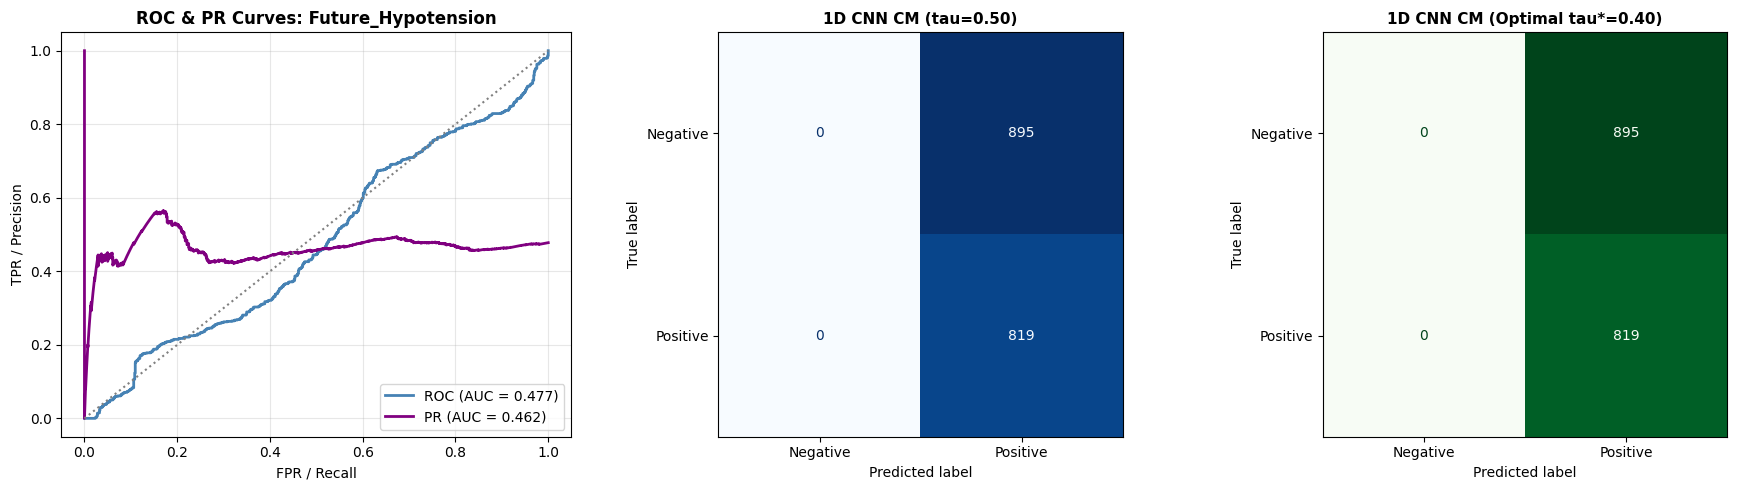

  SINGLE PATIENT METRICS: 1D CNN TFLite | TARGET: Future_Hypoxia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.25)
----------------------------------------------------------------------------
AUROC (ROC AUC)         : nan                  nan
AUPRC (PR AUC)          : nan                  nan
Accuracy                : 0.0000                  0.0000
Balanced Accuracy       : 0.0000                  0.0000
Sensitivity / Recall    : 0.0000                  0.0000
Specificity (TNR)       : 0.0000                  0.0000
Precision (PPV)         : 0.0000                  0.0000
F1 Score                : 0.0000                  0.0000
MCC                     : 0.0000                  0.0000
----------------------------------------------------------------------------
Confusion Matrix (0.50) : TN=0, FP=1714, FN=0, TP=0
Confusion Matrix (tau*) : TN=0, FP=1714, FN=0, TP=0



/home/logan78/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/logan78/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


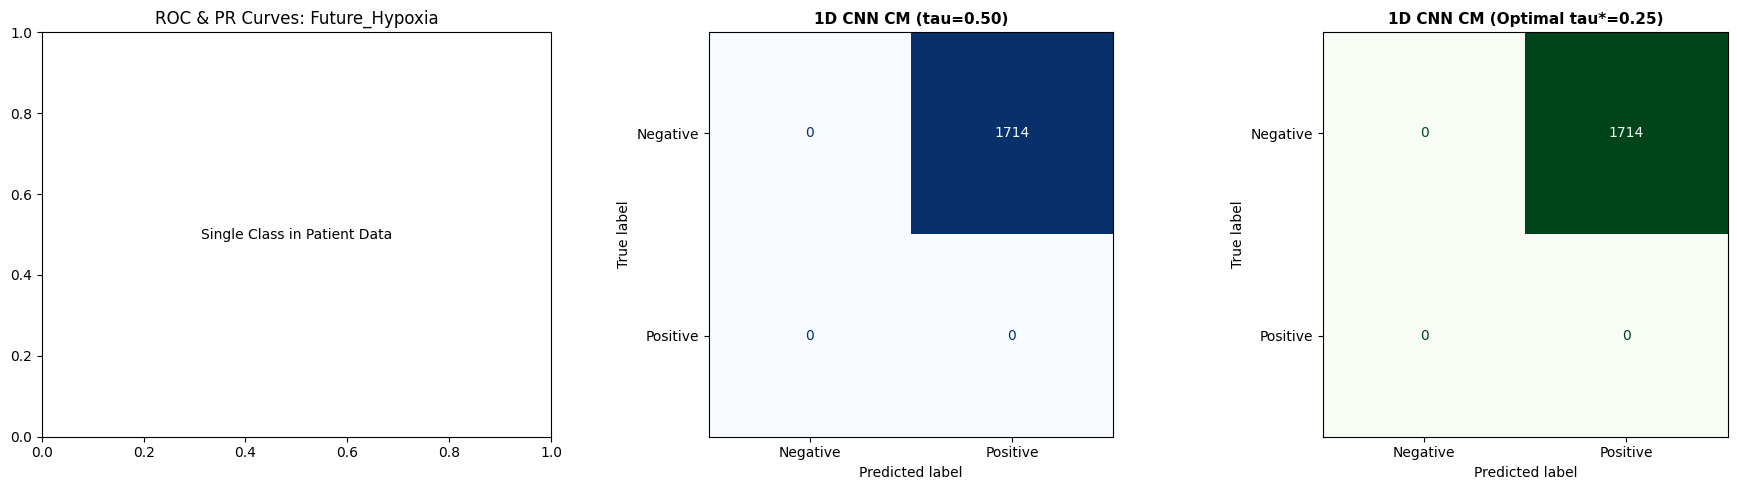

  SINGLE PATIENT METRICS: 1D CNN TFLite | TARGET: Future_Tachycardia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.45)
----------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.4819                  0.4819
AUPRC (PR AUC)          : 0.0975                  0.0975
Accuracy                : 0.1114                  0.1114
Balanced Accuracy       : 0.5000                  0.5000
Sensitivity / Recall    : 1.0000                  1.0000
Specificity (TNR)       : 0.0000                  0.0000
Precision (PPV)         : 0.1114                  0.1114
F1 Score                : 0.2005                  0.2005
MCC                     : 0.0000                  0.0000
----------------------------------------------------------------------------
Confusion Matrix (0.50) : TN=0, FP=1523, FN=0, TP=191
Confusion Matrix (tau*) : TN=0, FP=1523, FN=0, TP=191



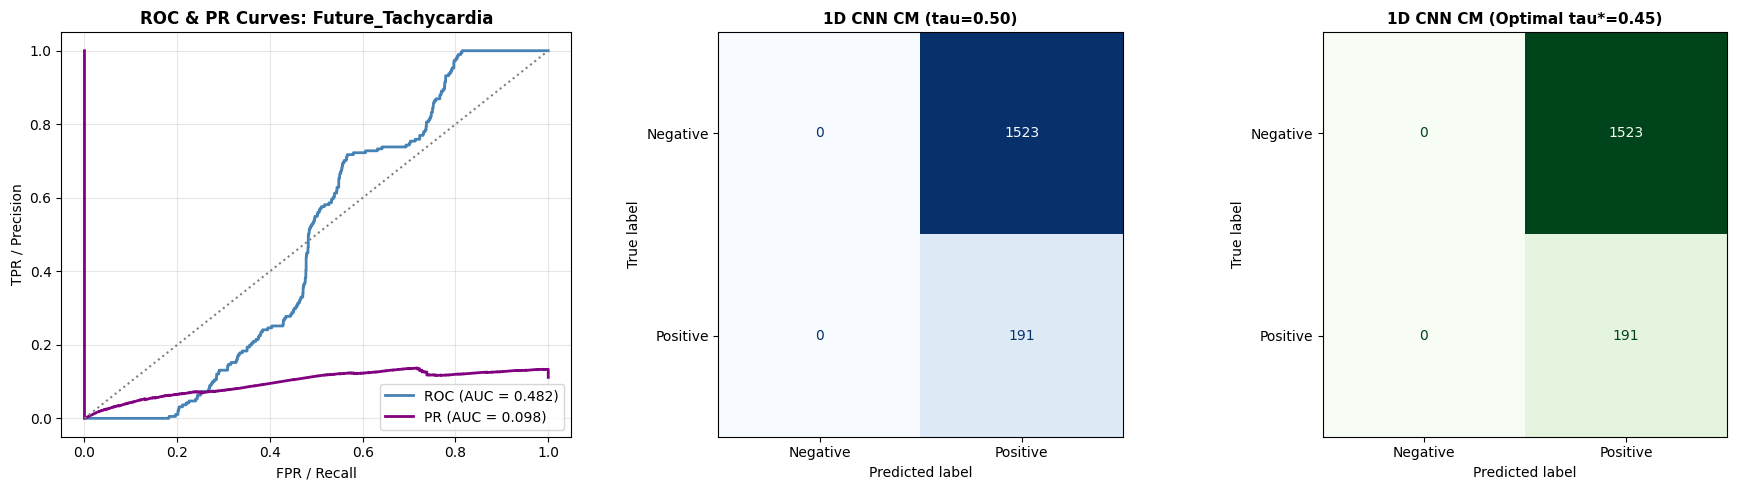

In [4]:
optimal_taus = {
    "Future_Hypotension": 0.40,
    "Future_Hypoxia": 0.25,
    "Future_Tachycardia": 0.45
}

for target in target_cols:
    if f"{target}_True" in df_preds.columns:
        y_true = df_preds[f"{target}_True"].to_numpy()
        y_prob = df_preds[f"{target}_Prob"].to_numpy()
        tau = optimal_taus.get(target, 0.50)
        
        print_metrics_table(target, y_true, y_prob, tau)
        plot_evaluation_charts(target, y_true, y_prob, tau)

In [5]:
# Output single patient predictions to CSV
out_filename = f"cnn_single_patient_predictions_{p_id}.csv"
csv_out_path = os.path.join(base_dir, "CNN", out_filename)

os.makedirs(os.path.dirname(csv_out_path), exist_ok=True)
df_preds.to_csv(csv_out_path, index=False)
print(f"[Export Success] Predictions for {p_id} saved to CSV: {csv_out_path}")
print(f"CSV Rows: {len(df_preds)} | Columns: {list(df_preds.columns)}")
df_preds.head()

[Export Success] Predictions for patient_1002 saved to CSV: /home/logan78/Desktop/SiLabs/CNN/CNN/cnn_single_patient_predictions_patient_1002.csv
CSV Rows: 1714 | Columns: ['patient_id', 'window_end_sec', 'Future_Hypotension_True', 'Future_Hypotension_Prob', 'Future_Hypotension_Pred', 'Future_Hypoxia_True', 'Future_Hypoxia_Prob', 'Future_Hypoxia_Pred', 'Future_Tachycardia_True', 'Future_Tachycardia_Prob', 'Future_Tachycardia_Pred']


,patient_id,window_end_sec,Future_Hypotension_True,Future_Hypotension_Prob,Future_Hypotension_Pred,Future_Hypoxia_True,Future_Hypoxia_Prob,Future_Hypoxia_Pred,Future_Tachycardia_True,Future_Tachycardia_Prob,Future_Tachycardia_Pred
0,patient_1002,600,1.0,0.992615,1,0.0,1.0,1,0.0,0.999995,1
1,patient_1002,605,1.0,0.991715,1,0.0,1.0,1,0.0,0.999994,1
2,patient_1002,610,1.0,0.990335,1,0.0,1.0,1,0.0,0.999994,1
3,patient_1002,615,1.0,0.989207,1,0.0,1.0,1,0.0,0.999994,1
4,patient_1002,620,1.0,0.987189,1,0.0,1.0,1,0.0,0.999989,1
